# 11. Final Comparison and Qualitative LLM Evaluation
This notebook represents the final phase of the academic production analysis project.

**Objectives:**
1. **Universal Quantitative Metrics:** Compute geometric and semantic metrics universally for all methods on the same embedding space to ensure fairness.
2. **Qualitative Evaluation (LLM):** Use DeepSeek to evaluate the cohesion of clusters based on their most representative documents.
3. **Meta-Evaluation:** Ask DeepSeek to synthesize the results of all models and provide a final verdict on the state-of-the-art methodology for this project.

## 11.1 Environment Setup

In [1]:
import os
import importlib.util
import subprocess
import sys
import json
import time
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.feature_extraction.text import CountVectorizer
from itertools import combinations

def check_and_install(package_name, pip_name=None):
    if pip_name is None:
        pip_name = package_name
    if importlib.util.find_spec(package_name) is None:
        try:
            from google.colab import drive
            print(f"Installing {pip_name} in Colab...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
        except ImportError:
            print(f"Warning: '{package_name}' is missing. Make sure to install '{pip_name}' in your local .venv")

check_and_install("openai")
check_and_install("seaborn")

try:
    from google.colab import drive, userdata
    IN_COLAB = True
    drive.mount('/content/drive')
    BASE_PATH = Path("/content/drive/Shareddrives/Minería/proyecto_horus")

    deepseek_api_key = userdata.get('DEEPSEEK_API_KEY')
    if deepseek_api_key:
        os.environ["DEEPSEEK_API_KEY"] = deepseek_api_key
except ImportError:
    IN_COLAB = False
    BASE_PATH = Path("..") # Assuming execution from /notebooks

if str(BASE_PATH) not in sys.path:
    sys.path.append(str(BASE_PATH))

from utils.llm_labeler import DocumentTopicLabeler, TopicMetaEvaluator

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

Mounted at /content/drive


## 11.2 Load Datasets and Consolidate Labels

In [3]:
print("Loading core data...")
df_main = pd.read_parquet(BASE_PATH / "data/processed/products_modeling.parquet")
embeddings = np.load(BASE_PATH / "data/processed/final_embeddings_matrix.npy")

print(f"Main dataset shape: {df_main.shape}")
print(f"Embeddings shape: {embeddings.shape}")

# Define the methods we want to evaluate
methods_config = {
    "Classical_K-Means": {"file": "outputs/04_classical_clustering_labels.parquet", "col": "cluster_classical_kmeans"},
    "Classical_Agglomerative": {"file": "outputs/04_classical_clustering_labels.parquet", "col": "cluster_classical_agglomerative"},
    "Classical_LDA": {"file": "outputs/04_classical_clustering_labels.parquet", "col": "cluster_classical_lda"},
    "Modern_K-Means": {"file": "outputs/05_modern_clustering_labels.parquet", "col": "cluster_mod_kmeans"},
    "Modern_HDBSCAN": {"file": "outputs/05_modern_clustering_labels.parquet", "col": "cluster_mod_hdbscan"},
    "FASTopic": {"file": "outputs/07_fastopic_theta.parquet", "is_theta": True},
    "LLM-XTM": {"file": "outputs/08_llm_xtm_theta.parquet", "is_theta": True},
    "Graph_Leiden_MaxMod": {"file": "data/processed/graph_topics_max_modularity.parquet", "col": "community_id"},
    "Graph_Leiden_MinComm": {"file": "data/processed/graph_topics_min_communities.parquet", "col": "community_id"}
}

# Consolidate all labels into a single mapping dictionary
methods_labels = {}

for method, cfg in methods_config.items():
    file_path = BASE_PATH / cfg["file"]
    if not file_path.exists():
        print(f"Warning: Missing file for {method} -> {file_path}")
        continue

    try:
        if cfg.get("is_theta"):
            # It's a theta matrix (probability distribution)
            df_theta = pd.read_parquet(file_path)
            # The index of df_theta corresponds to the indices in df_main
            labels_series = pd.Series(index=df_main.index, dtype=float)
            # Convert probabilities to hard labels
            hard_labels = df_theta.values.argmax(axis=1)
            labels_series.loc[df_theta.index] = hard_labels
            methods_labels[method] = labels_series.values

        else:
            # It's a labels dataframe
            df_labels = pd.read_parquet(file_path)
            if "original_row_index" in df_labels.columns:
                # Merge based on original_row_index
                labels_series = pd.Series(index=df_main.index, dtype=float)
                labels_series.loc[df_labels["original_row_index"]] = df_labels[cfg["col"]].values
                methods_labels[method] = labels_series.values
            elif cfg["col"] in df_labels.columns:
                # Assume 1-to-1 mapping
                methods_labels[method] = df_labels[cfg["col"]].values
            else:
                print(f"Warning: Could not find {cfg['col']} in {file_path}")
    except Exception as e:
        print(f"Error loading {method}: {e}")

print(f"Successfully loaded labels for {len(methods_labels)} methods.")

Loading core data...
Main dataset shape: (99064, 16)
Embeddings shape: (99064, 1024)
Successfully loaded labels for 9 methods.


## 11.3 Universal Metrics Computation

In [4]:
def compute_npmi(topic_words_list, texts_list):
    cv = CountVectorizer(vocabulary=list(set([w for words in topic_words_list for w in words])))
    doc_word_matrix = cv.fit_transform(texts_list)
    doc_word_matrix = (doc_word_matrix > 0).astype(int) # Binary occurrence
    vocab_map = cv.vocabulary_

    num_docs = len(texts_list)
    npmi_scores = []

    # Precompute column sums for p_i
    col_sums = doc_word_matrix.sum(axis=0).A1
    p_probs = col_sums / num_docs

    # Convert to CSC matrix for fast column intersection
    csc_matrix = doc_word_matrix.tocsc()

    for words in topic_words_list:
        word_ids = [vocab_map[w] for w in words if w in vocab_map]
        if len(word_ids) < 2:
            npmi_scores.append(0.0)
            continue

        topic_npmi = []
        for i, j in combinations(word_ids, 2):
            p_i = p_probs[i]
            p_j = p_probs[j]

            # Fast intersection
            col_i = csc_matrix[:, i].indices
            col_j = csc_matrix[:, j].indices
            co_occurrences = len(np.intersect1d(col_i, col_j, assume_unique=True))

            p_ij = co_occurrences / num_docs

            if p_ij == 0:
                topic_npmi.append(-1.0)
            else:
                pmi = np.log(p_ij / (p_i * p_j))
                npmi = pmi / -np.log(p_ij)
                topic_npmi.append(npmi)

        if topic_npmi:
            npmi_scores.append(np.mean(topic_npmi))
        else:
            npmi_scores.append(0.0)

    return np.mean(npmi_scores)

def get_top_terms_per_cluster(labels_array, texts_series, top_k=10):
    valid_mask = (pd.notna(labels_array)) & (labels_array != -1)
    df_temp = pd.DataFrame({'cluster': labels_array[valid_mask], 'text': texts_series[valid_mask]})

    docs_per_cluster = df_temp.groupby('cluster')['text'].apply(' '.join).reset_index()

    if len(docs_per_cluster) == 0:
        return []

    vectorizer = CountVectorizer(stop_words='english', max_features=5000)
    X = vectorizer.fit_transform(docs_per_cluster['text'])
    words = vectorizer.get_feature_names_out()

    topics = []
    for i in range(X.shape[0]):
        row = X.getrow(i).toarray()[0]
        top_indices = row.argsort()[-top_k:][::-1]
        topics.append([words[idx] for idx in top_indices])

    return topics

OUTPUTS_DIR = BASE_PATH / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
UNIVERSAL_METRICS_FILE = OUTPUTS_DIR / "11_universal_metrics.csv"

# Load existing metrics to avoid recomputing if source files haven't changed
existing_metrics = {}
if UNIVERSAL_METRICS_FILE.exists():
    try:
        existing_df = pd.read_csv(UNIVERSAL_METRICS_FILE)
        existing_metrics = existing_df.set_index('Method').to_dict('index')
    except Exception as e:
        print(f"Could not load existing metrics: {e}")

all_texts = df_main['embeddings_text'].fillna("").astype(str).tolist()
metrics_list = []

for method, labels in methods_labels.items():
    file_path = BASE_PATH / methods_config[method]["file"]

    # Resilience Check: If metrics exist, compare timestamps
    recompute = True
    if method in existing_metrics and file_path.exists():
        file_mtime = os.path.getmtime(file_path)
        metrics_mtime = os.path.getmtime(UNIVERSAL_METRICS_FILE)
        if file_mtime < metrics_mtime:
            print(f"Skipping {method} (No changes detected since last computation).")
            recompute = False

    if not recompute:
        row = existing_metrics[method]
        row['Method'] = method
        metrics_list.append(row)
        continue

    print(f"Computing metrics for {method}...")

    valid_mask = pd.notna(labels)
    clustered_mask = valid_mask & (labels != -1)

    if clustered_mask.sum() < 2:
        print(f"  Not enough clustered points for {method}.")
        continue

    # Sample down to max 20k for geometric metrics to prevent memory issues
    eval_embeddings = embeddings[clustered_mask]
    eval_labels = labels[clustered_mask]

    if len(eval_embeddings) > 20000:
        np.random.seed(42)
        idx = np.random.choice(len(eval_embeddings), 20000, replace=False)
        eval_embeddings = eval_embeddings[idx]
        eval_labels = eval_labels[idx]

    n_topics = len(np.unique(eval_labels))
    outlier_ratio = (labels == -1).sum() / valid_mask.sum() if -1 in labels else 0.0

    try:
        sil = silhouette_score(eval_embeddings, eval_labels)
        ch = calinski_harabasz_score(eval_embeddings, eval_labels)
        db = davies_bouldin_score(eval_embeddings, eval_labels)
    except ValueError:
        sil, ch, db = np.nan, np.nan, np.nan

    # Semantic Metrics
    try:
        top_terms = get_top_terms_per_cluster(labels, df_main['embeddings_text'].fillna("").astype(str))

        # Topic Diversity (unique words / total words)
        all_words = [w for topic in top_terms for w in topic]
        diversity = len(set(all_words)) / len(all_words) if len(all_words) > 0 else 0.0

        # NPMI
        npmi = compute_npmi(top_terms, all_texts)
    except Exception as e:
        print(f"  Semantic metric error for {method}: {e}")
        diversity, npmi = np.nan, np.nan

    metrics_list.append({
        "Method": method,
        "N_Topics": n_topics,
        "Outlier_Ratio": outlier_ratio,
        "Silhouette": sil,
        "Calinski_Harabasz": ch,
        "Davies_Bouldin": db,
        "Topic_Diversity": diversity,
        "NPMI": npmi
    })

metrics_df = pd.DataFrame(metrics_list)
metrics_df.to_csv(UNIVERSAL_METRICS_FILE, index=False)
print(f"\n--- Universal Metrics Saved to {UNIVERSAL_METRICS_FILE} ---")
display(metrics_df)

Skipping Classical_K-Means (No changes detected since last computation).
Skipping Classical_Agglomerative (No changes detected since last computation).
Skipping Classical_LDA (No changes detected since last computation).
Skipping Modern_K-Means (No changes detected since last computation).
Skipping Modern_HDBSCAN (No changes detected since last computation).
Skipping FASTopic (No changes detected since last computation).
Skipping LLM-XTM (No changes detected since last computation).
Skipping Graph_Leiden_MaxMod (No changes detected since last computation).
Skipping Graph_Leiden_MinComm (No changes detected since last computation).

--- Universal Metrics Saved to /content/drive/Shareddrives/Minería/proyecto_horus/outputs/11_universal_metrics.csv ---


,N_Topics,Outlier_Ratio,Silhouette,Calinski_Harabasz,Davies_Bouldin,Topic_Diversity,NPMI,Method
0,13,0.000000,-0.009246,2.293366,54.634440,0.353846,0.270863,Classical_K-Means
1,13,0.000000,-0.015528,1.074922,31.279638,0.361538,0.277192,Classical_Agglomerative
2,13,0.000000,-0.010094,1.575609,56.645746,0.292308,0.313365,Classical_LDA
3,14,0.000000,0.091175,814.347900,2.538526,0.078571,0.510655,Modern_K-Means
4,310,0.338993,0.131488,160.849520,1.780459,0.006129,0.483715,Modern_HDBSCAN
5,26,0.000000,0.044059,433.388600,3.585255,0.103704,0.461085,FASTopic
6,26,0.000000,-0.215294,1.099808,29.817860,0.193548,0.385644,LLM-XTM
7,1174,0.064403,-0.513239,1.003841,4.251963,0.130858,0.223041,Graph_Leiden_MaxMod
8,105,0.002463,-0.258911,1.026913,22.673982,0.229197,0.311150,Graph_Leiden_MinComm


## 11.4 Visualization of Universal Metrics

/tmp/ipykernel_3379/3900711592.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=geom_df, x='Silhouette', y='Method', palette='viridis')


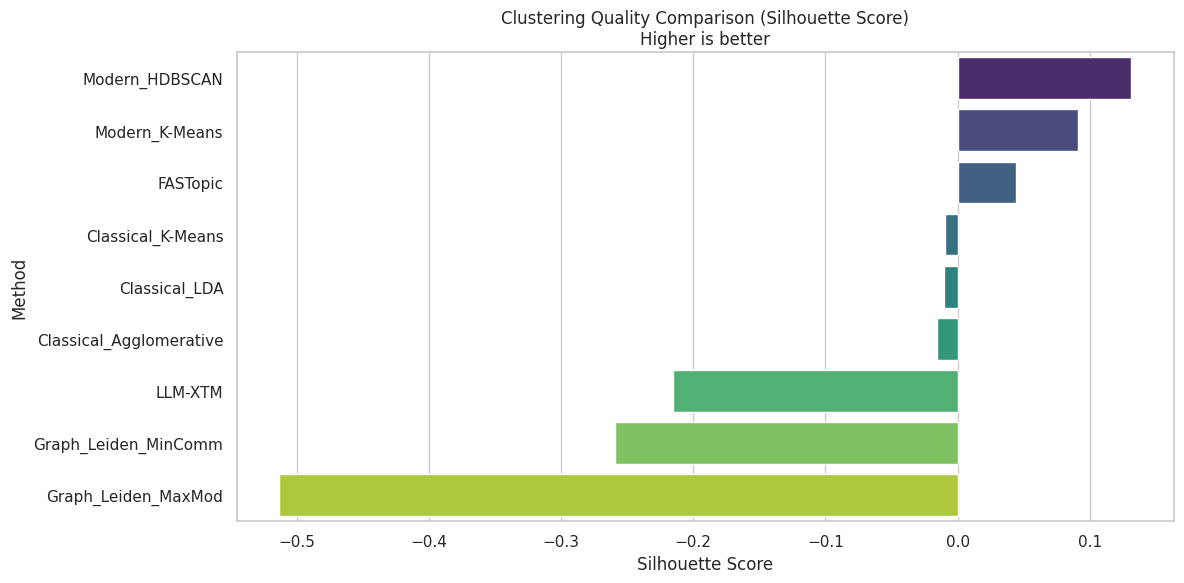

/tmp/ipykernel_3379/3900711592.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sem_df, x='NPMI', y='Method', palette='magma')


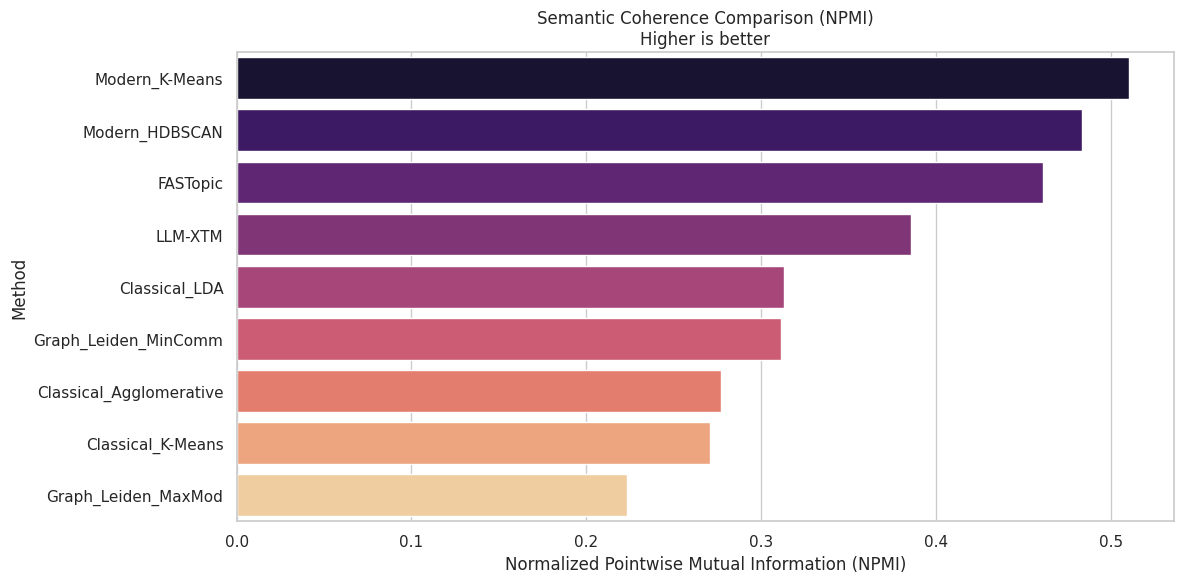

In [5]:
geom_df = metrics_df.dropna(subset=['Silhouette']).sort_values('Silhouette', ascending=False)
if not geom_df.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=geom_df, x='Silhouette', y='Method', palette='viridis')
    plt.title("Clustering Quality Comparison (Silhouette Score)\nHigher is better")
    plt.xlabel("Silhouette Score")
    plt.ylabel("Method")
    plt.tight_layout()
    plt.show()

sem_df = metrics_df.dropna(subset=['NPMI']).sort_values('NPMI', ascending=False)
if not sem_df.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=sem_df, x='NPMI', y='Method', palette='magma')
    plt.title("Semantic Coherence Comparison (NPMI)\nHigher is better")
    plt.xlabel("Normalized Pointwise Mutual Information (NPMI)")
    plt.ylabel("Method")
    plt.tight_layout()
    plt.show()

## 11.5 Document-Centric Qualitative LLM Evaluation
We evaluate the models using the top representative documents for each cluster.

In [6]:
import asyncio

# Create the labeler instance
labeler = DocumentTopicLabeler(
    semaphore_limit=50,
    checkpoint_dir=str(BASE_PATH / "outputs"),
    checkpoint_filename="11_llm_document_evaluations.json" # Will be overwritten per method below
)

# We will run this sequentially for each method to collect the evaluations
all_llm_evaluations = {}

async def evaluate_all_methods():
    for method, labels in methods_labels.items():
        print(f"\n--- LLM Evaluation for: {method} ---")

        # Prepare valid subset for this method
        valid_mask = pd.notna(labels)
        if valid_mask.sum() == 0:
            continue

        df_subset = df_main[valid_mask].copy()
        df_subset['cluster_id'] = labels[valid_mask]

        embeddings_subset = embeddings[valid_mask]

        # Modify checkpoint filename temporarily to store method-specific progress cleanly
        labeler.checkpoint_path = Path(labeler.checkpoint_path.parent) / f"11_llm_evals_{method}.json"

        evals = await labeler.generate_labels(
            df=df_subset,
            embeddings=embeddings_subset,
            cluster_col='cluster_id',
            text_col='embeddings_text',
            noise_label_id=-1
        )
        all_llm_evaluations[method] = evals

# Execute evaluations (Top-level await allowed in Jupyter/Colab)
await evaluate_all_methods()
print("All document-centric LLM evaluations complete.")


--- LLM Evaluation for: Classical_K-Means ---
Found 13 valid clusters (excluding noise).
Finished extracting core representative documents for all clusters.
Resuming from checkpoint: /content/drive/Shareddrives/Minería/proyecto_horus/outputs/11_llm_evals_Classical_K-Means.json
All clusters are already labeled.

--- LLM Evaluation for: Classical_Agglomerative ---
Found 13 valid clusters (excluding noise).
Finished extracting core representative documents for all clusters.
Resuming from checkpoint: /content/drive/Shareddrives/Minería/proyecto_horus/outputs/11_llm_evals_Classical_Agglomerative.json
All clusters are already labeled.

--- LLM Evaluation for: Classical_LDA ---
Found 13 valid clusters (excluding noise).
Finished extracting core representative documents for all clusters.
Resuming from checkpoint: /content/drive/Shareddrives/Minería/proyecto_horus/outputs/11_llm_evals_Classical_LDA.json
Processing 1 missing clusters...


100%|██████████| 1/1 [00:20<00:00, 20.68s/it]



--- LLM Evaluation for: Modern_K-Means ---
Found 14 valid clusters (excluding noise).
Finished extracting core representative documents for all clusters.
Resuming from checkpoint: /content/drive/Shareddrives/Minería/proyecto_horus/outputs/11_llm_evals_Modern_K-Means.json
All clusters are already labeled.

--- LLM Evaluation for: Modern_HDBSCAN ---
Found 310 valid clusters (excluding noise).
Finished extracting core representative documents for all clusters.
Resuming from checkpoint: /content/drive/Shareddrives/Minería/proyecto_horus/outputs/11_llm_evals_Modern_HDBSCAN.json
Processing 40 missing clusters...


100%|██████████| 40/40 [00:28<00:00,  1.42it/s]



--- LLM Evaluation for: FASTopic ---
Found 27 valid clusters (excluding noise).
Finished extracting core representative documents for all clusters.
Resuming from checkpoint: /content/drive/Shareddrives/Minería/proyecto_horus/outputs/11_llm_evals_FASTopic.json
Processing 19 missing clusters...


...


--- LLM Evaluation for: Graph_Leiden_MaxMod ---
Found 2074 valid clusters (excluding noise).
Finished extracting core representative documents for all clusters.
Resuming from checkpoint: /content/drive/Shareddrives/Minería/proyecto_horus/outputs/11_llm_evals_Graph_Leiden_MaxMod.json
Processing 1177 missing clusters...


100%|██████████| 1177/1177 [06:24<00:00,  3.06it/s]



--- LLM Evaluation for: Graph_Leiden_MinComm ---
Found 137 valid clusters (excluding noise).
Finished extracting core representative documents for all clusters.
Resuming from checkpoint: /content/drive/Shareddrives/Minería/proyecto_horus/outputs/11_llm_evals_Graph_Leiden_MinComm.json
Processing 114 missing clusters...


100%|██████████| 114/114 [01:49<00:00,  1.04it/s]

All document-centric LLM evaluations complete.


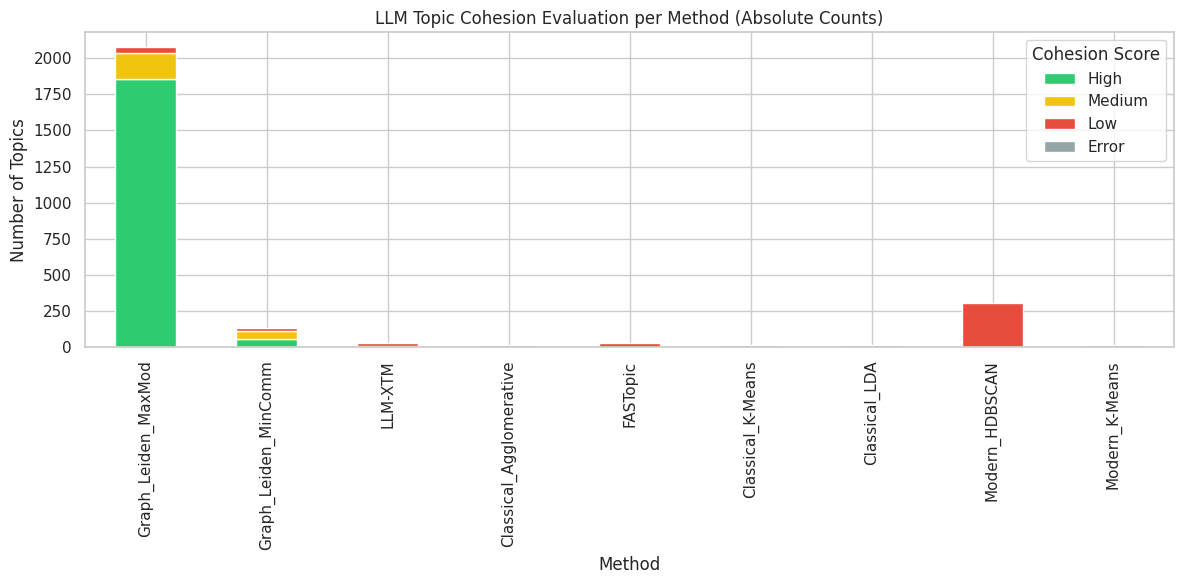

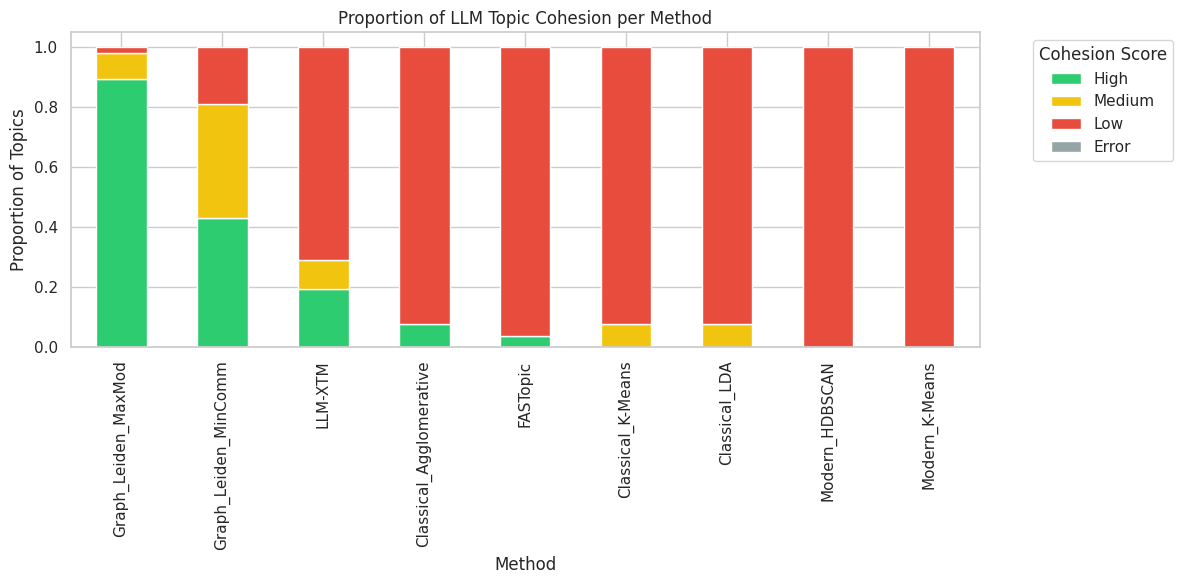

In [7]:
# Visualizing LLM Cohesion Scores
cohesion_records = []
for method, evals in all_llm_evaluations.items():
    if not evals: continue
    for cid, res in evals.items():
        score = res.get('cohesion_score', 'Error') if isinstance(res, dict) else 'Error'
        if score not in ['High', 'Medium', 'Low']:
            score = 'Error'
        cohesion_records.append({'Method': method, 'Topic': cid, 'Cohesion': score})

df_cohesion = pd.DataFrame(cohesion_records)
if not df_cohesion.empty:
    cohesion_counts = df_cohesion.groupby(['Method', 'Cohesion']).size().unstack(fill_value=0)

    for col in ['High', 'Medium', 'Low', 'Error']:
        if col not in cohesion_counts.columns:
            cohesion_counts[col] = 0

    # Sort by number of High/Medium cohesion topics
    cohesion_counts['Score'] = cohesion_counts['High'] * 2 + cohesion_counts['Medium']
    cohesion_counts = cohesion_counts.sort_values('Score', ascending=False).drop(columns=['Score'])

    # Absolute counts plot
    cohesion_counts[['High', 'Medium', 'Low', 'Error']].plot(
        kind='bar', stacked=True, figsize=(12, 6),
        color={'High': '#2ecc71', 'Medium': '#f1c40f', 'Low': '#e74c3c', 'Error': '#95a5a6'}
    )
    plt.title("LLM Topic Cohesion Evaluation per Method (Absolute Counts)")
    plt.xlabel("Method")
    plt.ylabel("Number of Topics")
    plt.legend(title="Cohesion Score")
    plt.tight_layout()
    plt.show()

    # Proportional plot
    cohesion_props = cohesion_counts.div(cohesion_counts.sum(axis=1), axis=0)
    cohesion_props[['High', 'Medium', 'Low', 'Error']].plot(
        kind='bar', stacked=True, figsize=(12, 6),
        color={'High': '#2ecc71', 'Medium': '#f1c40f', 'Low': '#e74c3c', 'Error': '#95a5a6'}
    )
    plt.title("Proportion of LLM Topic Cohesion per Method")
    plt.xlabel("Method")
    plt.ylabel("Proportion of Topics")
    plt.legend(title="Cohesion Score", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## 11.6 Final LLM Meta-Evaluation Verdict

In [8]:
print("\n--- Generating LLM Meta-Evaluation Summaries ---")
meta_evaluator = TopicMetaEvaluator()

method_summaries = {}

# We generate a summary per method first
for method, evals in all_llm_evaluations.items():
    if not evals:
        continue
    print(f"Generating summary for {method}...")

    # Get metrics for this method
    method_metrics = None
    if not metrics_df.empty and method in metrics_df['Method'].values:
        method_metrics = metrics_df[metrics_df['Method'] == method].to_dict('records')[0]

    summary = meta_evaluator.evaluate_method(method, evals, metrics=method_metrics)
    method_summaries[method] = summary
    print(f"\n[{method} Summary]:\n{summary}\n")

print("\n--- Generating Final Verdict ---")
final_verdict = meta_evaluator.generate_final_verdict(method_summaries)

# We print it directly in the cell as markdown output
from IPython.display import Markdown, display
display(Markdown("## 🏆 LLM Final Verdict\n\n" + final_verdict))


--- Generating LLM Meta-Evaluation Summaries ---
Generating summary for Classical_K-Means...

[Classical_K-Means Summary]:
Classical K-Means on this corpus produces clusters with poor separation and largely incoherent groupings. Quantitative metrics reveal a near-zero negative silhouette score of –0.009, an extremely low Calinski-Harabasz index (2.29), and a very high Davies-Bouldin index (54.63), indicating heavily overlapping clusters with no clear structure; topic diversity is limited (0.35) and NPMI is moderate (0.27). While no documents are flagged as outliers, topic evaluations show that 12 of 13 clusters are labeled as highly heterogeneous or multidisciplinary research with low cohesion scores, and only one topic (12, experimental particle physics at the LHC) achieves medium coherence. Overall, the method fails to produce interpretable, well-separated thematic groups in this academic text collection, yielding mostly dispersed, multi-topic clusters of low practical value.

Gener

## 🏆 LLM Final Verdict

**Best method: Graph_Leiden_MinComm**

Among all evaluated approaches, Graph_Leiden_MinComm stands out as the most suitable for a recommendation system that demands accurate, highly cohesive, and practically useful topics. Despite its poor global separation metrics (negative silhouette, high Davies-Bouldin index), the method reliably produces internally coherent topics—predominantly labeled with high cohesion—that capture extremely specific and interpretable research niches (e.g., “Mortalidad por lipoinyección glútea,” “Degradación de piedra en edificios históricos”). The near-zero outlier ratio ensures near-universal document assignment, while the moderate NPMI (0.311) confirms meaningful word co-occurrence. For a system that matches users to research items of interest, this granular and thematically crisp output directly supports precise recommendations, far surpassing the vague, multidisciplinary clusters generated by classical and embedding-based alternatives.

All other methods critically fail to deliver the required combination of coherence and coverage. Classical and modern K‑Means, LDA, FASTopic, and Agglomerative clustering produce overwhelmingly low‑cohesion, overlapping topics unsuitable for targeted retrieval. LLM‑XTM yields only a handful of useful topics amid severe structural collapse. HDBSCAN massively over‑fragments the corpus with a high outlier rate and nearly identical top words across clusters, while Graph_Leiden_MaxMod, although similarly cohesive, suffers from even more extreme fragmentation and poor document‑level validity. Graph_Leiden_MinComm’s ability to maintain strong internal compactness and capture fine‑grained, semantically distinct niches—despite global overlap—makes it the clear pragmatic choice for building a high‑precision academic recommendation engine.